In [1]:

###############################################################################
#             PREPARAÇÃO DA BASE DE DADOS                                     #
###############################################################################

RANDOM_SEED = 42
# Vamos evitar a notacao cientifica nos resultados
options(scipen = 999)

## Instala pacotes necessários (instala apenas os ausentes, sem prompt)
required_pkgs <- c("yarrr", "plyr", "readr", "dplyr", "caret", "ggplot2", "repr", "glmnet", "fastDummies", "tidyverse")
install_if_missing <- function(pkgs) {
  missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]
  if(length(missing)) install.packages(missing, repos = "https://cloud.r-project.org")
}
install_if_missing(required_pkgs)


In [2]:
# Carregando os pacotes necessarios
library(plyr)
library(readr)
library(dplyr)
library(caret)
library(ggplot2)
library(repr)
library(glmnet)
library(fastDummies)
#library(tidyverse)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:plyr’:

    arrange, count, desc, failwith, id, mutate, rename, summarise,
    summarize


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: lattice

Loading required package: Matrix

Loaded glmnet 5.0



In [3]:
# Carrega o arquivo .RData e atribui o primeiro objeto carregado a 'dat'
loaded_names <- load("trabalhosalarios.RData")
dat <- get(loaded_names[1])
# Mostrar quais objetos foram carregados (debug)
#print(loaded_names)

#head(dat)

In [4]:
# Checar valores faltantes no dataset 'dat'
na_count <- sum(is.na(dat))

if (na_count > 0) {
  cat("Há", na_count, "valores faltantes\n")
  # Contagem de NA por coluna
  print(sapply(dat, function(x) sum(is.na(x))))
} else {
  cat("Não há valores faltantes\n")
}


Não há valores faltantes


In [5]:
# Transformando colunas  em variaveis dummy (categóricas) 

#1. Transformar em colunas dummies ( “quebrar” a categoria em números 0/1 para o modelo enxergar.)
#Finalidade:
#deixar a variável utilizável por modelos que só aceitam números, como glmnet;
#evitar dar uma ordem falsa para categorias;
#representar cada categoria separadamente no modelo.

#2. Transformar em factor (usado no ElasticNet)
#informar ao R/caret que a variável é qualitativa;
#fazer com que a interface por fórmula trate essa coluna como categoria e gere a codificação apropriada internamente;
#preservar o significado categórico durante o ajuste, especialmente quando você usa train(..., method = "glmnet") com fórmula.

dat <- dummy_cols(dat, select_columns = c("husunion", "husblck", "hushisp", "kidge6", "black", "hispanic", "union", "kidlt6"), 
                        remove_most_frequent_dummy=FALSE, 
                        remove_selected_columns=TRUE)
#str(dat)

In [6]:
# Essa semente de numeros aleatorios serve para
# particionar o dataset aleatoriamente
set.seed(RANDOM_SEED)  

# Vamos criar um indice para particionar o dataset em
# 80% para treinamento
percentual_treino <- 0.8 # 80% para treinamento e 20% para teste
index = sample(1:nrow(dat), percentual_treino * nrow(dat))

# Vamos criar a base de dados de treinamento
train = dat[index,]  

# Vamos criar a base de dados de teste
test = dat[-index,] 

# Vamos checar as dimensoes das bases de treinamento e 
# teste
dim(train)
dim(test)
# A base de treinamento possui 75 linhas e 
# 10 colunas (variaveis)
# A base de teste possui 75 linhas e 10
# colunas (variaveis)

[1] 2059   25

[1] 515  25

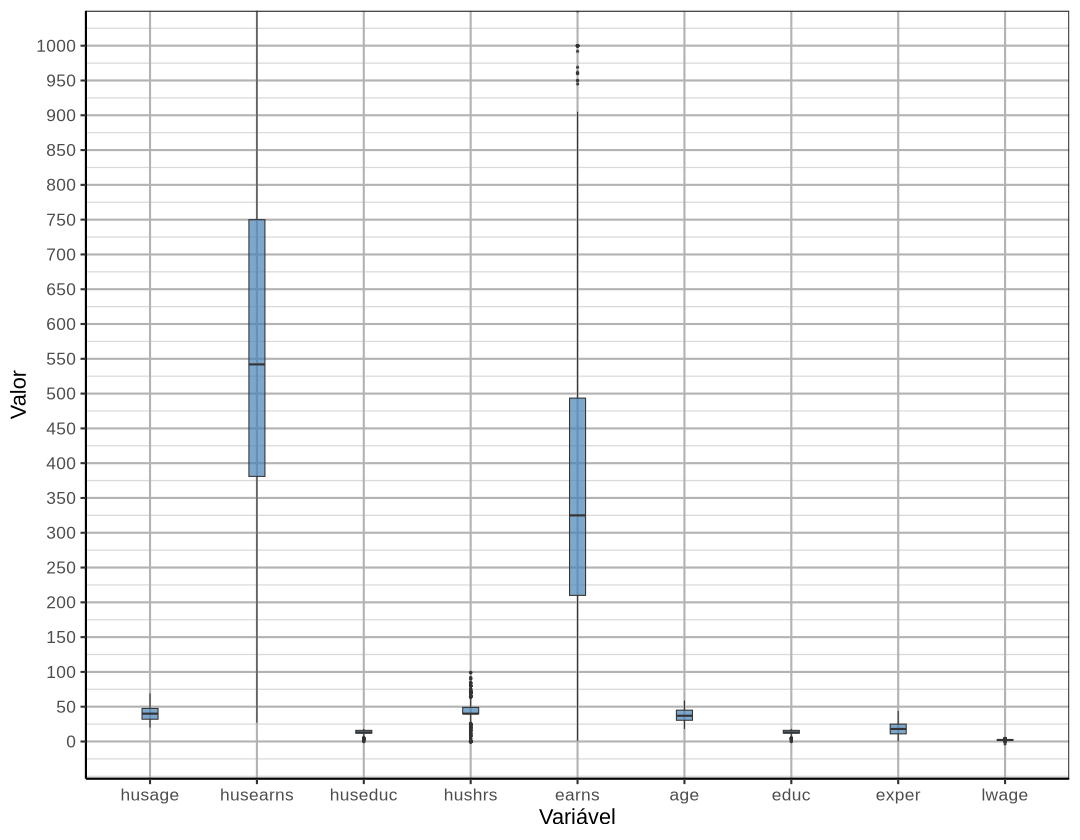

In [7]:
# Mostra um boxplot por variável para comparar escalas
# Facilita pra decidir se é necessário padronizar as variáveis

# Do enunciado, a variável dependente é "lwage" (log do salário)
# É uma mudança de escala, não está padronizada

# Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 9, repr.plot.height = 7)

train[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.15, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  coord_cartesian(ylim = c(NA, 1000)) +
  scale_y_continuous(breaks = seq(0, 1000, by = 50)) +
  labs(x = "Variável", y = "Valor") +  # rótulos dos eixos
  theme_bw(base_size = 13) +
  theme(
    axis.line = element_line(color = "black"),
    panel.grid.major = element_line(color = "grey70", linewidth = 0.6),
    panel.grid.minor = element_line(color = "grey85", linewidth = 0.35)
  )

In [8]:
# Padronizando com z-score 

# incluir variável dependente na padronização?
# se padronizar , lembrar de no final despadronizar e fazer exp(lwage)
cols <- c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")
pre_proc_val <- caret::preProcess(train[,cols], 
                           method = c("center", "scale")) # calcula média e desvio-padrão para cada coluna selecionada.

train1 <- train # necessário para criar uma cópia do dataset original e aplicar a padronização apenas nas colunas selecionadas, mantendo as outras colunas inalteradas.
train1[,cols] <- predict(pre_proc_val, train[,cols]) # realiza a padronização de fato nas colunas selecionadas

#head(train1)


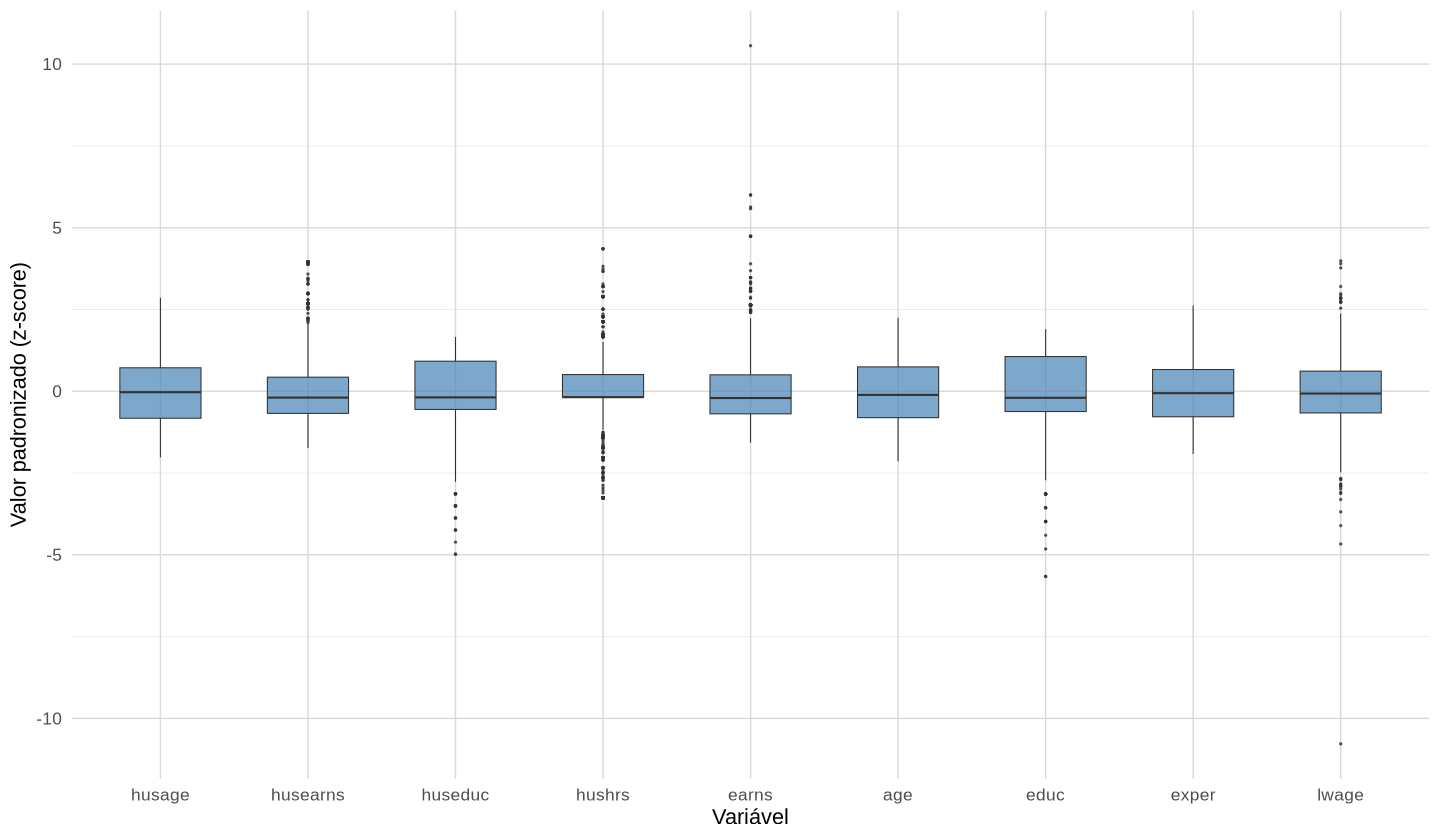

In [9]:
# Verificando os boxplots após a padronização
 # Amplia só um pouco o tamanho do gráfico na saída do notebook
options(repr.plot.width = 12, repr.plot.height = 7)

train1[, c("husage", "husearns", "huseduc", "hushrs", "earns", "age", "educ", "exper", "lwage")] %>%  # escolhe colunas
  stack() %>%  # coloca em formato longo (variável/valor)
  ggplot(aes(x = ind, y = values)) +  # inicia o gráfico com um único eixo x e um único eixo y
  geom_boxplot(fill = "steelblue", alpha = 0.7, width = 0.55, linewidth = 0.3, outlier.size = 0.3) +  # desenha boxplots
  labs(x = "Variável", y = "Valor padronizado (z-score)") +  # rótulos dos eixos
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major = element_line(color = "grey85", linewidth = 0.4),
    panel.grid.minor = element_line(color = "grey92", linewidth = 0.25)
  )

In [10]:
# Padronizando a base de teste usando os parâmetros calculados na base de treino
test1 <- test
test1[,cols] <- predict(pre_proc_val, test[,cols]) # aplica centro e escala calculados em 'train'


#head(test1)

In [11]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
train1 <- train1 %>% select(lwage, everything()) # train1 é a base de treino padronizada
#head(train1)


In [12]:

# Guardando os valores das variáveis explicativas em 'x'
# colunas 2 a última de train1 convertidas para uma matriz: é a matriz de preditores
x <- as.matrix(train1[,2:ncol(train1)])
#ncol(train1)
#head(x)

In [13]:
# Vamos guardar o vetor de dados de treinamento da 
# variavel dependente para o modelo em um objeto
# chamado "y_train"
y_train = train1$lwage
#head(y_train)

In [14]:
# reordenando o dataset porque a coluna "lwage" esta no meio do dataset
test1 <- test1 %>% select(lwage, everything()) # teste1 é a base de teste padronizada
#head(test1)

In [15]:
# Vamos guardar a matriz de dados de teste das variaveis
# explicativas para o modelo em um objeto chamado
# "x_test"
x_test = as.matrix(test1[,2:ncol(test1)]) # test1 é a base de teste padronizada
#ncol(test1)
#head(x_test)

In [16]:
# Vamos guardar o vetor de dados de teste da variavel
# dependente para o modelo em um objeto chamado "y_test"
y_test = test1$lwage

In [ ]:
###############################################################################
#                               REGRESSAO RIDGE                               #
###############################################################################


# Nova implementacao: usamos caret::train com repeated cross-validation para selecionar lambda
# Mantemos a mesma faixa de lambdas usada antes para compatibilidade.
library(caret)
library(glmnet)

train_cont <- trainControl(method = "cv",
                           number = 5,
                           savePredictions = "final")

## equivalente a:
#train_cont <- trainControl(method = "repeatedcv",
#                           number = 5,
#                           repeats = 1,
#                           savePredictions = "final")

#set.seed(RANDOM_SEED) # reprodutibilidade das dobras

# Grade de lambda (10^-3 a 10^2) - usamos 50 pontos na escala log
ridge_grid <- expand.grid(alpha = 0,
                          lambda = 10^seq(2, -3, length = 50))

# Treina o modelo Ridge com tuning via repeated CV
ridge_reg <- train(x = x, y = y_train,
                   method = "glmnet",
                   trControl = train_cont,
                   tuneGrid = ridge_grid,
                   metric = "RMSE")

ridge_reg[["beta"]]


NULL

In [19]:
# Estimando o modelo Ridge
#ridge_reg = glmnet(x, y_train, alpha = 0, 
#                   family = 'gaussian', 
#                   lambda = best_lambda_ridge,
#                   standardize = FALSE) #standardize = TRUE por padrão, mas já padronizamos manualmente

# Vamos ver o resultado (valores) da estimativa 
# (coeficientes)
#ridge_reg[["beta"]]

In [20]:
# Vamos calcular o R^2 dos valores verdadeiros e 
# preditos conforme a seguinte funcao:
eval_results <- function(true, predicted, df) {
  SSE <- sum((predicted - true)^2)
  SST <- sum((true - mean(true))^2)
  R_square <- 1 - SSE / SST
  RMSE = sqrt(SSE/nrow(df))
  
# As metricas de performace do modelo:
  data.frame(
    RMSE = RMSE,
    Rsquare = R_square
  )
}



In [21]:
# Predicao e avaliacao nos dados de treinamento:
# Usamos newdata = data.frame para compatibilidade com objetos caret::train
predictions_train <- predict(ridge_reg, newdata = as.data.frame(x))


In [22]:
# As metricas da base de treinamento sao:
ridge_result_train <- eval_results(y_train, predictions_train, train1)
ridge_result_train

RMSE,Rsquare
<dbl>,<dbl>
0.5566528,0.6899871


In [23]:
# Predicao e avaliacao nos dados de teste:
predictions_test <- predict(ridge_reg, newdata = as.data.frame(x_test))


In [24]:

# As metricas da base de teste sao:
ridge_result_test <- eval_results(y_test, predictions_test, test1)
ridge_result_test
# Se compararmos as metricas de treinamento e teste
# vemos que o tamanho dos erros de treinamento e teste
# e os R^2 sao parecidos, o que descarta a hipotese
# de overfitting e underfitting. 

RMSE,Rsquare
<dbl>,<dbl>
0.5751896,0.6787887


In [25]:
###############################################################################
#                               REGRESSAO LASSO                               #
###############################################################################

lasso_grid <- expand.grid(alpha = 1,
                          lambda = 10^seq(2, -3, length = 50))

lasso_reg <- train(x = x, y = y_train,
                   method = "glmnet",
                   trControl = train_cont, # reusa o mesmo controle de treinamento do Ridge
                   tuneGrid = lasso_grid,
                   metric = "RMSE")

#lasso_reg[["beta"]]

Warning message in nominalTrainWorkflow(x = x, y = y, wts = weights, info = trainInfo, :
“There were missing values in resampled performance measures.”


In [26]:
# Predicoes e avaliacao nos dados de treinamento
predictions_train_lasso <- predict(lasso_reg, newdata = as.data.frame(x))

lasso_result_train <- eval_results(y_train, predictions_train_lasso, train1)
#lasso_result_train

In [27]:
# Predicoes e avaliacao nos dados de teste
predictions_test_lasso <- predict(lasso_reg, newdata = as.data.frame(x_test))

lasso_result_test <- eval_results(y_test, predictions_test_lasso, test1)
#lasso_result_test

In [28]:
###############################################################################
#                              REGRESSAO ELASTICNET                           #
###############################################################################

# Elastic Net combina Ridge e Lasso e escolhe alpha e lambda por CV.
# Vamos configurar o treinamento do modelo por 
# cross validation, com 10 folders, 5 repeticoes
# e busca aleatoria dos componentes das amostras
# de treinamento, o "verboseIter" eh soh para 
# mostrar o processamento.

# por que aqui foi usado trainControl ao inves de cv.glmnet?
# trainControl (usado com caret::train) permite buscar simultaneamente por alpha e lambda usando CV configurável
#
# cv.glmnet: faz cross‑validation eficiente sobre a sequência de lambda gerada pelo glmnet, 
#mas não escolhe alpha automaticamente.


# Nos nao temos o parametro "alpha", porque a regressao
# ElasticNet vai encontra-lo automaticamente, cujo valor
# estara entre 0 e 1 (para Ridge ==> alpha = 0; e
# para Lasso ==> alpha = 1).
# O parametro "lambda" tambem eh escolhido por
# cross-validation

In [29]:
# Vamos treinar o modelo

# No glmnet puro, voce eh obrigado a escolher um alpha fixo (ex: 0.5)
# modelo_en <- glmnet(X, y, alpha = 0.5)
# O glmnet puro eh excelente quando voce ja sabe o valor de alpha que quer usar 
# (0 para Ridge, 1 para Lasso, ou um valor fixo como 0.5).
# Mas o ElasticNet exige encontrar o melhor equilibrio de 
# dois parametros ao mesmo tempo:
# o alpha (o mix entre Ridge/Lasso) e o lambda (o tamanho da multa).

elastic_reg <- train(
  x = x,
  y = y_train,
  method = "glmnet",
  tuneLength = 10,
  trControl = train_cont, # reusa o mesmo controle de treinamento do Ridge e Lasso
  standardize = FALSE
)


In [30]:
# O melhor parametro alpha escolhido eh:
#elastic_reg$bestTune


In [31]:
# E os parametros sao:
#elastic_reg[["finalModel"]][["beta"]]

In [32]:
# Vamos fazer as predicoes e avaliar a performance do
# modelo

# Vamos fazer as predicoes no modelo de treinamento:
predictions_train <- predict(elastic_reg, newdata = as.data.frame(x))

In [33]:
# As metricas de performance na base de treinamento
# sao:
elasticnet_result_train <- eval_results(y_train, predictions_train, train1) 
#elasticnet_result_train

In [34]:
# Vamos fazer as predicoes na base de teste
predictions_test <- predict(elastic_reg, newdata = as.data.frame(x_test))

# As metricas de performance na base de teste sao:
elasticnet_result_test <- eval_results(y_test, predictions_test, test1)
#elasticnet_result_test

In [35]:
############################################
### PREDIÇÃO PARA O ENUNCIADO DO TRABALHO  #
############################################

# Como os valores do dataset sao padronizados, nos temos
# de padronizar tambem os dados que vamos fazer a predicao.
# Note que as variaveis dummies nao devem ser padronizadas.

# Valores fornecidos no enunciado
husage <- 40
husunion <- 0
husearns <- 600
huseduc <- 13
husblck <- 1
hushisp <- 0
hushrs <- 40
kidge6 <- 1
# 'earns' usará a média da variável 'earns' na base de treinamento,
# já que não foi fornecido um valor específico para essa variável no enunciado.
# Autorizado via email do professor Razer, dia 5 de Abril
earns <- mean(train$earns)
age <- 38
black <- 0
educ <- 13
hispanic <- 1
union <- 0
exper <- 18
kidlt6 <- 1


In [36]:
## Padronizando usando os mesmos parametros da base de treino

# As variaveis numericas serao padronizadas com media e desvio da base de treino
# As variaveis dummy (0/1) serao mantidas sem padronizacao

# Dummies: manter como estao
# husunion, husblck, hushisp, kidge6, black, hispanic, union, kidlt6

# Montar data.frame com a mesma ordem e nomes das colunas usadas no treino
# (as dummies foram criadas com sufixo _0 e _1 pelo fastDummies)

our_pred = as.matrix(data.frame(
  husage = (husage - mean(train$husage)) / sd(train$husage),
  husearns = (husearns - mean(train$husearns)) / sd(train$husearns),
  huseduc = (huseduc - mean(train$huseduc)) / sd(train$huseduc),
  hushrs = (hushrs - mean(train$hushrs)) / sd(train$hushrs),
  earns = (earns - mean(train$earns)) / sd(train$earns),
  age = (age - mean(train$age)) / sd(train$age),
  educ = (educ - mean(train$educ)) / sd(train$educ),
  exper = (exper - mean(train$exper)) / sd(train$exper),
  husunion_0 = as.integer(husunion == 0),
  husunion_1 = as.integer(husunion == 1),
  husblck_0 = as.integer(husblck == 0),
  husblck_1 = as.integer(husblck == 1),
  hushisp_0 = as.integer(hushisp == 0),
  hushisp_1 = as.integer(hushisp == 1),
  kidge6_0 = as.integer(kidge6 == 0),
  kidge6_1 = as.integer(kidge6 == 1),
  black_0 = as.integer(black == 0),
  black_1 = as.integer(black == 1),
  hispanic_0 = as.integer(hispanic == 0),
  hispanic_1 = as.integer(hispanic == 1),
  union_0 = as.integer(union == 0),
  union_1 = as.integer(union == 1),
  kidlt6_0 = as.integer(kidlt6 == 0), # se kidlt6 eh 0, kidlt6_0 eh 1; se kidlt6 eh 1, kidlt6_0 eh 0
  kidlt6_1 = as.integer(kidlt6 == 1) # se kidlt6 eh 1, kidlt6_1 eh 1; caso contrario, eh 0
))



In [37]:

predict_our_ridge <- as.numeric(predict(ridge_reg, newdata = as.data.frame(our_pred)))

predict_our_lasso <- as.numeric(predict(lasso_reg, newdata = as.data.frame(our_pred)))

predict_our_elastic <- as.numeric(predict(elastic_reg, newdata = as.data.frame(our_pred)))

# Mostrar os valores padronizados (lwage na escala padronizada)
#predict_our_ridge
#predict_our_lasso
#predict_our_elastic


In [38]:
# O resultado eh padronizado; primeiro voltamos para a escala de lwage
# e, como lwage ja eh o log do salario, aplicamos exp no final

lwage_value <- function(model_predict) {

  lwage_pred_log <- (model_predict * sd(train$lwage) + mean(train$lwage))
  return(lwage_pred_log)
}

lwage_pred_ridge_log <- lwage_value(predict_our_ridge)
lwage_pred_ridge <- exp(lwage_pred_ridge_log)
#lwage_pred_ridge

lwage_pred_lasso_log <- lwage_value(predict_our_lasso)
lwage_pred_lasso <- exp(lwage_pred_lasso_log)
#lwage_pred_lasso

lwage_pred_elastic_log <- lwage_value(predict_our_elastic)
lwage_pred_elastic <- exp(lwage_pred_elastic_log)
#lwage_pred_elastic



In [39]:
CI_lwage_range <- function(lwage_pred_log) {
  
  n <- nrow(train)
  m <- lwage_pred_log
  s <- sd(train$lwage)
  dam <- s / sqrt(n)
  
  CIlwr_log <- m + (qnorm(0.025)) * dam
  CIupr_log <- m - (qnorm(0.025)) * dam
  
  CIlwr <- exp(CIlwr_log)
  CIupr <- exp(CIupr_log)
  
  return(c(CIlwr, CIupr))
}

CI_ridge <- CI_lwage_range(lwage_pred_ridge_log)
CI_lasso <- CI_lwage_range(lwage_pred_lasso_log)
CI_elastic <- CI_lwage_range(lwage_pred_elastic_log)

# Como acessar os limites superior e inferior do intervalo de confiança para o modelo Ridge:
CI_ridge_lower <- CI_ridge[1]
#CI_ridge_lower
CI_ridge_upper <- CI_ridge[2]
#CI_ridge_upper

# Como acessar os limites superior e inferior do intervalo de confiança para o modelo Lasso:
CI_lasso_lower <- CI_lasso[1]
#CI_lasso_lower
CI_lasso_upper <- CI_lasso[2]
#CI_lasso_upper

# Como acessar os limites superior e inferior do intervalo de confiança para o modelo ElasticNet:
CI_elastic_lower <- CI_elastic[1]
#CI_elastic_lower
CI_elastic_upper <- CI_elastic[2]
#CI_elastic_upper
#

In [40]:
# Resultado final:
# Tabela com RMSE e R2 (base de teste)
model_metrics <- rbind(
  data.frame(Model = "Ridge", Dataset = "Teste", RMSE = ridge_result_test$RMSE, Rsquare = ridge_result_test$Rsquare),
  data.frame(Model = "Lasso", Dataset = "Teste", RMSE = lasso_result_test$RMSE, Rsquare = lasso_result_test$Rsquare),
  data.frame(Model = "ElasticNet", Dataset = "Teste", RMSE = elasticnet_result_test$RMSE, Rsquare = elasticnet_result_test$Rsquare)
 )

# ordena por RMSE decrescente
#model_metrics <- model_metrics[order(model_metrics$RMSE, -model_metrics$Rsquare), ] 
model_metrics

# Predicoes com intervalos de confianca
pred_table <- rbind(
  data.frame(Model = "Ridge", Predicao = as.numeric(lwage_pred_ridge), CI_Lower = as.numeric(CI_ridge_lower), CI_Upper = as.numeric(CI_ridge_upper)),
  data.frame(Model = "Lasso", Predicao = as.numeric(lwage_pred_lasso), CI_Lower = as.numeric(CI_lasso_lower), CI_Upper = as.numeric(CI_lasso_upper)),
  data.frame(Model = "ElasticNet", Predicao = as.numeric(lwage_pred_elastic), CI_Lower = as.numeric(CI_elastic_lower), CI_Upper = as.numeric(CI_elastic_upper))
 )

pred_table


Model,Dataset,RMSE,Rsquare
<chr>,<chr>,<dbl>,<dbl>
Ridge,Teste,0.5751896,0.6787887
Lasso,Teste,0.5742971,0.6797849
ElasticNet,Teste,0.5736796,0.6804730


Model,Predicao,CI_Lower,CI_Upper
<chr>,<dbl>,<dbl>,<dbl>
Ridge,9.322100,9.114973,9.533934
Lasso,9.210113,9.005474,9.419402
ElasticNet,9.071771,8.870206,9.277916
